# Analysis of Tolstoy’s and Dostoevsky’s vocabularies

In [1]:
# !pip install beautifulsoup4 scikit-learn scipy --quiet
# !pip install pymorphy2 pymorphy2-dicts-ru --quiet

### Preliminary part

In [2]:
import re
import time
from collections import Counter
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from scipy.stats import anderson
from sklearn.feature_extraction.text import TfidfVectorizer

---

### Fetching Texts from az.lib.ru

In [3]:
HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; educational-research)'}


def fetch_azlib(author_url, keywords):
    resp = requests.get(author_url, headers=HEADERS, timeout=30)
    resp.encoding = 'cp1251'
    soup = BeautifulSoup(resp.text, 'html.parser')
    for a in soup.find_all('a', href=True):
        anchor = a.get_text(strip=True).lower()
        if any(kw in anchor for kw in keywords):
            href = urljoin(author_url, a['href'])
            page = requests.get(href, headers=HEADERS, timeout=180)
            page.encoding = 'cp1251'
            body = BeautifulSoup(page.text, 'html.parser')
            return body.get_text(separator=' ')
    raise ValueError(f"No link matching {keywords!r} on {author_url}")

In [4]:
TOLSTOY_URL = 'http://az.lib.ru/t/tolstoj_lew_nikolaewich/'
DOSTOEVSKY_URL = 'http://az.lib.ru/d/dostoewskij_f_m/'

raw_tolstoy = fetch_azlib(TOLSTOY_URL, ['война и мир'])
time.sleep(2)
raw_dostoevsky = fetch_azlib(DOSTOEVSKY_URL, ['братья карамазов'])

print(f"Tolstoy raw chars: {len(raw_tolstoy):,}")
print(f"Dostoevsky raw chars: {len(raw_dostoevsky):,}")

Tolstoy raw chars: 740,847
Dostoevsky raw chars: 380,757


### Tokenization

In [5]:
def tokenize(text):
    return re.findall(r'[а-яёa-z]+', text.lower())

tokens_tolstoy = tokenize(raw_tolstoy)
tokens_dostoevsky = tokenize(raw_dostoevsky)

print(f"Tolstoy tokens: {len(tokens_tolstoy):,}")
print(f"Dostoevsky tokens: {len(tokens_dostoevsky):,}")

Tolstoy tokens: 111,651
Dostoevsky tokens: 61,091


---

## Heaps' Law Analysis (both Tolstoy and Dostoevsky)

### We are building vocabulary Growth Curves

In [6]:
!pip install pymorphy2 pymorphy2-dicts-ru --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
def vocab_growth(tokens, n_points=1000):
    n = len(tokens)
    step = max(1, n // n_points)
    vocab = set()
    sizes, counts = [], []
    for i, token in enumerate(tokens, 1):
        vocab.add(token)
        if i % step == 0:
            sizes.append(len(vocab))
            counts.append(i)
    if not sizes or counts[-1] != n:
        sizes.append(len(vocab))
        counts.append(n)
    return np.array(counts, dtype=float), np.array(sizes, dtype=float)

In [8]:
rng = np.random.default_rng(42)

tol_shuf = rng.permutation(tokens_tolstoy).tolist()
dos_shuf = rng.permutation(tokens_dostoevsky).tolist()

x_to, y_to = vocab_growth(tokens_tolstoy)
x_ts, y_ts = vocab_growth(tol_shuf)
x_do, y_do = vocab_growth(tokens_dostoevsky)
x_ds, y_ds = vocab_growth(dos_shuf)

In [9]:
def fit_heaps(x, y):
    lx, ly = np.log(x), np.log(y)
    coef = np.polyfit(lx, ly, 1)
    beta, log_K = coef
    K = np.exp(log_K)
    residuals = ly - np.polyval(coef, lx)
    return K, beta, coef, lx, ly, residuals


curves = [
    ('Tolstoy - original', x_to, y_to, 'steelblue',  '-'),
    ('Tolstoy - shuffled', x_ts, y_ts, 'magenta',  '--'),
    ('Dostoevsky - original', x_do, y_do, 'darkorange', '-'),
    ('Dostoevsky - shuffled', x_ds, y_ds, 'cyan', '--'),
]

fit_heaps_params = {}
print(f"{'Curve':<30s}  {'K':>10s}  {'β':>10s}")
print('-' * 55)
for label, x, y, *_ in curves:
    K, beta, coef, lx, ly, res = fit_heaps(x, y)
    fit_heaps_params[label] = {
        'K': K, 'beta': beta, 'coef': coef,
        'lx': lx, 'ly': ly, 'residuals': res,
    }
    print(f"{label:<30s}  {K:>10.4f}  {beta:>10.4f}")

Curve                                    K           β
-------------------------------------------------------
Tolstoy - original                  3.9628      0.7404
Tolstoy - shuffled                  5.7842      0.7089
Dostoevsky - original               2.6469      0.7772
Dostoevsky - shuffled               3.6610      0.7470


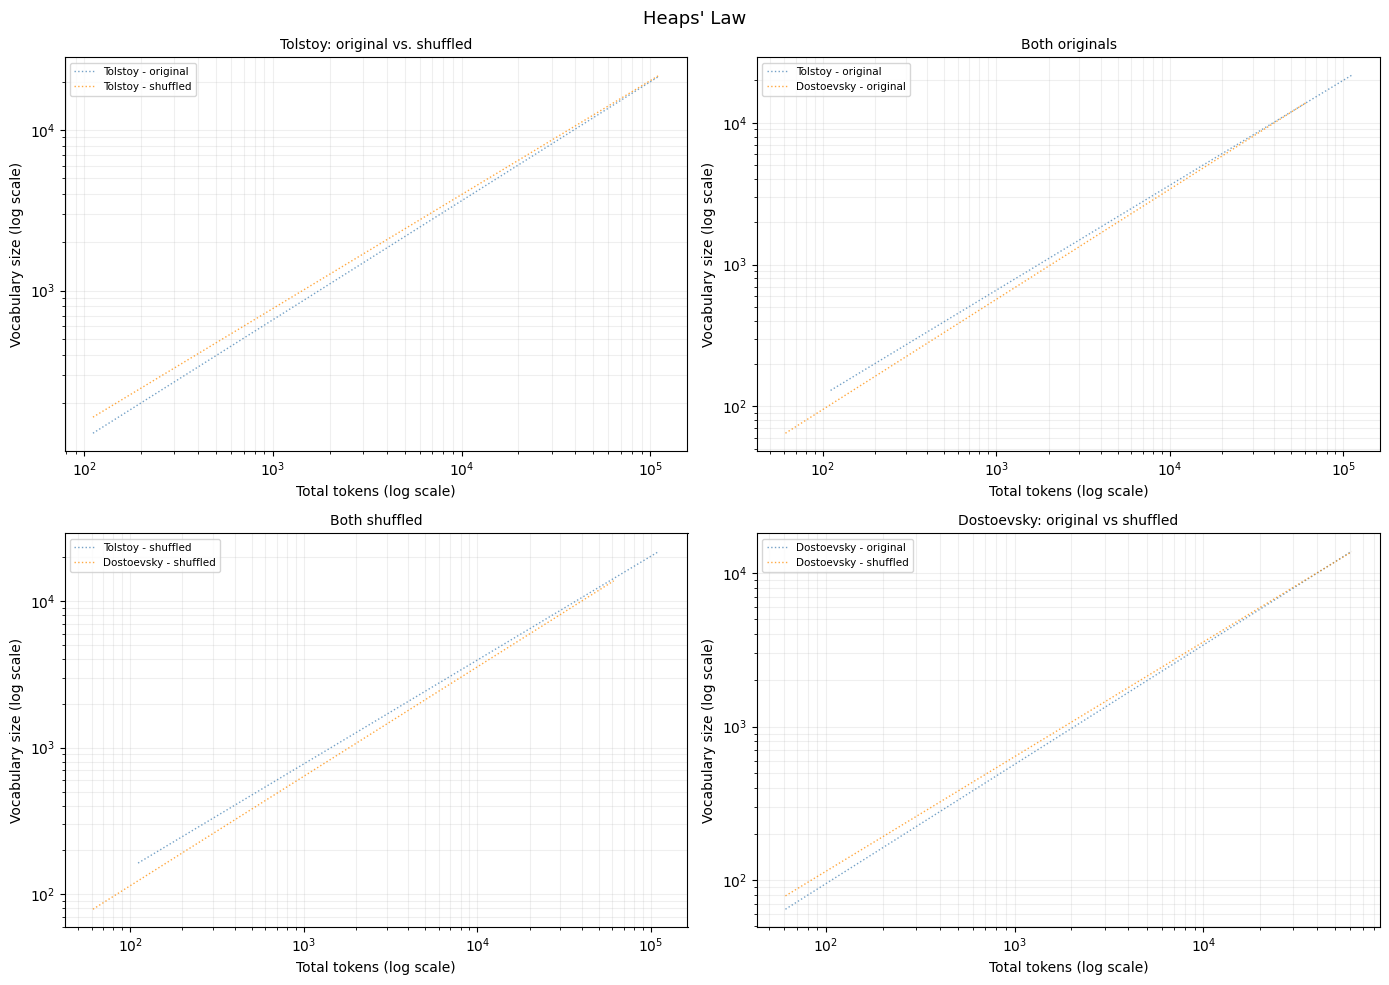

In [18]:
curves_dict = {label: (x, y) for label, x, y, *_ in curves}

def plot_pair(ax, label_a, label_b, title):
    for label, color in [(label_a, 'steelblue'), (label_b, 'darkorange')]:
        x, y = curves_dict[label]
        fp = fit_heaps_params[label]
        y_fit = np.exp(np.polyval(fp['coef'], fp['lx']))
        legend_label = f"{label}  (β={fp['beta']:.3f})"
        ax.loglog(x, y_fit, color=color, ls=':', linewidth=1.0, alpha=0.75, label=f"{label}")
    ax.set_xlabel('Total tokens (log scale)')
    ax.set_ylabel('Vocabulary size (log scale)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, which='both', alpha=0.2)


pairs = [
    ('Tolstoy - original', 'Tolstoy - shuffled', 'Tolstoy: original vs. shuffled'),
    ('Tolstoy - original', 'Dostoevsky - original', 'Both originals'),
    ('Tolstoy - shuffled', 'Dostoevsky - shuffled', 'Both shuffled'),
    ('Dostoevsky - original', 'Dostoevsky - shuffled', 'Dostoevsky: original vs shuffled'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (la, lb, title) in zip(axes.flatten(), pairs):
    plot_pair(ax, la, lb, title)

plt.suptitle("Heaps' Law", fontsize=13)
plt.tight_layout()
plt.show()

---

## Поиск характерных слов Толстого и Достоевского

In [13]:
import pickle
from functools import lru_cache

import pymorphy2

SW_RU_URL = (
    'https://raw.githubusercontent.com/stopwords-iso/stopwords-ru'
    '/master/stopwords-ru.txt'
)
resp = requests.get(SW_RU_URL, timeout=15)
stopwords_ru = resp.text.strip().split('\n')
print(f"Всего русских стоп-слов: {len(stopwords_ru)}")

Всего русских стоп-слов: 559


In [14]:
stopwords_ru[:15]

['c',
 'а',
 'алло',
 'без',
 'белый',
 'близко',
 'более',
 'больше',
 'большой',
 'будем',
 'будет',
 'будете',
 'будешь',
 'будто',
 'буду']

In [15]:
from tqdm.notebook import tqdm

In [16]:
morph = pymorphy2.MorphAnalyzer()

@lru_cache(maxsize=None)
def lemma(word):
    return morph.parse(word)[0].normal_form


lemmas_tolstoy = [lemma(tok) for tok in tqdm(tokens_tolstoy)]
lemmas_dostoevsky = [lemma(tok) for tok in tqdm(tokens_dostoevsky)]

print(f"лемм у Толстого: {len(set(lemmas_tolstoy)):,}")
print(f"лемм у Достоевского: {len(set(lemmas_dostoevsky)):,}")

  0%|          | 0/111651 [00:00<?, ?it/s]

  0%|          | 0/61091 [00:00<?, ?it/s]

лемм у Толстого: 10,364
лемм у Достоевского: 6,945


In [17]:
freq_lem_tol = Counter(lemmas_tolstoy)
freq_lem_dos = Counter(lemmas_dostoevsky)
freq_raw_tol = Counter(tokens_tolstoy)
freq_raw_dos = Counter(tokens_dostoevsky)

TOP_N = 20


def top_content(freq, stopwords, n=TOP_N):
    return [(w, c) for w, c in freq.most_common() if w not in stopwords][:n]


tl_lem = top_content(freq_lem_tol, stopwords_ru)
dl_lem = top_content(freq_lem_dos, stopwords_ru)
tl_raw = top_content(freq_raw_tol, stopwords_ru)
dl_raw = top_content(freq_raw_dos, stopwords_ru)

pd.DataFrame({
    'леммы Толстого': [f"{w} ({c})" for w, c in tl_lem],
    'слова Толстого': [f"{w} ({c})" for w, c in tl_raw],
    'леммы Достоевского': [f"{w} ({c})" for w, c in dl_lem],
    'слова Достоевского': [f"{w} ({c})" for w, c in dl_raw],
}, index=range(1, TOP_N + 1))

,леммы Толстого,слова Толстого,леммы Достоевского,слова Достоевского
1,князь (876),князь (626),алеш (275),алеша (200)
2,чт (514),чт (514),старец (189),федор (127)
3,андрей (382),андрей (296),павлович (175),павлович (122)
4,пьер (344),ростов (232),иван (173),федорович (118)
5,ростов (320),de (214),фёдорович (172),иван (115)
6,офицер (230),пьер (213),фёдор (169),старец (97)
7,княжна (217),vous (179),дмитрий (109),пред (77)
8,de (214),князя (155),брат (103),дмитрий (68)
9,анна (214),анна (153),иванович (94),знаю (65)
10,солдат (190),княжна (141),нибыть (87),григорий (65)
